Load Solitude from OSM\n\nParses `data/osm/UT/Solitude.osm` into a `Mountain` object using the new backend (`core/support/mountain.py`). This drives the full ingestion pipeline: OSM parsing → elevation lookup → vertical/difficulty calculation → historical weather lookup.\n\nRun this notebook with the repo root as the working directory (it uses relative paths like `data/cache_db.db`)."

In [5]:
from core.support.mountain import Mountain
from core.datamodels.season_pass import Season_Pass

OSM_FILE = "data/osm/UT/Solitude.osm"

Build the `Mountain` from the OSM file. This hits the real elevation and weather APIs (caching elevation lookups in `data/cache_db.db`), so it can take a bit on first run.

In [6]:
season_passes = [Season_Pass.IKON]
url = "https://www.solitudemountain.com"

mountain = Mountain.from_osm(OSM_FILE, season_passes, url)
mountain

Output()

Output()

Mountain(mountain_id=UUID('3b8b83fd-87d0-3db5-b794-0a1672a3795f'), name='Solitude', state=<State.UTAH: 'UT'>, direction='w', coordinates=<POINT (-111.603 40.613)>, season_passes=[<Season_Pass.IKON: 'Ikon'>], url='https://www.solitudemountain.com', vertical=753, difficulty=49.2, beginner_friendliness=14.9, average_icy_days=55.8, average_snow=173.17, average_rain=0.39, last_updated=datetime.datetime(2026, 8, 5, 22, 45, 48, 956387), trails={'w618345132': Trail(trail_id='w618345132', mountain_id=UUID('3b8b83fd-87d0-3db5-b794-0a1672a3795f'), geometry={'type': 'LineString', 'coordinates': [[Decimal('-111.595014'), Decimal('40.609400'), 2748.333984375], [Decimal('-111.595009'), Decimal('40.609454'), 2747.23974609375], [Decimal('-111.595004'), Decimal('40.609509'), 2746.021240234375], [Decimal('-111.594998'), Decimal('40.609563'), 2744.814453125], [Decimal('-111.594993'), Decimal('40.609617'), 2743.2578125], [Decimal('-111.594988'), Decimal('40.609671'), 2741.515380859375], [Decimal('-111.5949

## Summary stats

In [7]:
print(f"Name: {mountain.name}")
print(f"Mountain ID: {mountain.mountain_id}")
print(f"State: {mountain.state}")
print(f"Region: {mountain.region()}")
print(f"Coordinates: {mountain.coordinates}")
print(f"Direction: {mountain.direction}")
print(f"Vertical: {mountain.vertical} m")
print(f"Difficulty: {mountain.difficulty}")
print(f"Beginner friendliness: {mountain.beginner_friendliness}")
print(f"Average icy days: {mountain.average_icy_days}")
print(f"Average snow: {mountain.average_snow}")
print(f"Average rain: {mountain.average_rain}")
print(f"Trail count: {mountain.trail_count()}")
print(f"Lift count: {mountain.lift_count()}")

Name: Solitude
Mountain ID: 3b8b83fd-87d0-3db5-b794-0a1672a3795f
State: State.UTAH
Region: Region.WEST
Coordinates: POINT (-111.60340338218293 40.61304926725796)
Direction: w
Vertical: 753 m
Difficulty: 49.2
Beginner friendliness: 14.9
Average icy days: 55.8
Average snow: 173.17
Average rain: 0.39
Trail count: 90
Lift count: 9


## Area geometry sampling

Area trails (glades, bowls) store two point sets: `geometry` is the sampled boundary ring, `interior_geometry` is the interior sampling grid used for slope calculations. Plot both for one area trail to sanity-check the sampling.

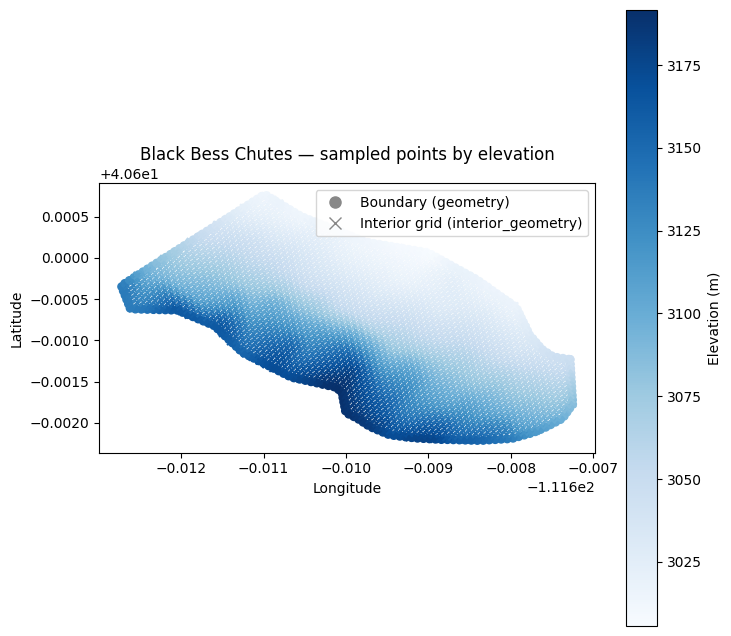

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

area_trail = next(trail for trail in mountain.trails.values() if trail.area)

boundary_points = area_trail.geometry["coordinates"][0]
interior_points = area_trail.interior_geometry["coordinates"]

boundary_lon, boundary_lat, boundary_elev = zip(*boundary_points)
interior_lon, interior_lat, interior_elev = zip(*interior_points)

all_elev = boundary_elev + interior_elev
vmin, vmax = min(all_elev), max(all_elev)
cmap = plt.get_cmap("Blues")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary_lon, boundary_lat, color="#c7c7c7", linewidth=1, zorder=1)
points = ax.scatter(
    boundary_lon,
    boundary_lat,
    c=boundary_elev,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    marker="o",
    s=30,
    zorder=2,
)
ax.scatter(
    interior_lon,
    interior_lat,
    c=interior_elev,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    marker="x",
    s=30,
    zorder=2,
)

# color now encodes elevation, so category (boundary vs. interior) is carried by
# marker shape alone -- legend uses neutral gray proxies to show that mapping
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#888888",
        markeredgecolor="#888888",
        markersize=8,
        label="Boundary (geometry)",
    ),
    Line2D(
        [0],
        [0],
        marker="x",
        linestyle="none",
        color="#888888",
        markersize=8,
        label="Interior grid (interior_geometry)",
    ),
]
ax.legend(handles=legend_handles)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{area_trail.name or area_trail.trail_id} — sampled points by elevation")
ax.set_aspect("equal")

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Elevation (m)")

plt.show()

## Route finding: least-steep path down

Goal: from the highest sampled point in the area to the lowest, find a ski line whose single steepest pitch is as gentle as possible (a *bottleneck* objective), without turning into a long sideways wander to shave off a fraction of a degree.

Pure greedy steepest-descent (walk to whichever neighbor is least steep, repeat) can zig-zag or dead-end, since it only ever looks one step ahead. Instead this uses a two-phase least-cost-path approach over a graph built from the sampled points:

1. **Bottleneck pass** — a modified Dijkstra where a path's cost is its *worst* edge, not the sum of edges. This finds the minimum possible steepest-pitch value (`slope_limit`) needed to connect top and bottom at all.
2. **Least-wandering pass** — start from a loose slope cap (60°) and tighten it in 5° steps toward `slope_limit`, tracking route length at each cap (ordinary distance-weighted Dijkstra restricted to edges at or below the current cap). The route length at the very first (loosest) pass is the baseline; stop tightening as soon as a cap's route length exceeds a fixed multiple of that baseline (default 1.5x), and use the previous cap — the last one still within budget.

Graph edges only connect points at least `BOTTLENECK_WINDOW_METERS` (30m) apart, capped at `NEIGHBOR_RADIUS_METERS` (45m) so the graph stays local. This mirrors `core/support/utils.py`'s `get_trail_difficulty`, which only counts a pitch if it's sustained over at least 30m (`steepest_30m`) — connecting points ~6-11m apart (the raw `polygon_interior_grid` sample spacing) would make the bottleneck sensitive to noise between two adjacent samples rather than reflecting real sustained steepness. Slope itself is still `atan(rise / run)` in degrees, same as `get_slope_profile`.

In [ ]:
import heapq
from collections import defaultdict
from math import atan, degrees

import haversine as hs
import numpy as np

BOTTLENECK_WINDOW_METERS = 30  # matches get_trail_difficulty's steepest_30m -- slope only "counts" if sustained over >= 30m
NEIGHBOR_RADIUS_METERS = BOTTLENECK_WINDOW_METERS * 1.5  # generous margin above the window so the graph stays well-connected near the area boundary

raw_nodes = list(boundary_points) + list(interior_points)
# OSM coordinates come through as Decimal (osm_processor rounds via Decimal());
# cast to float so numpy/math ops downstream work
nodes = [(float(p[0]), float(p[1]), float(p[2])) for p in raw_nodes if p[2] is not None]

node_lon = np.array([p[0] for p in nodes])
node_lat = np.array([p[1] for p in nodes])
node_elev = np.array([p[2] for p in nodes])
n_nodes = len(nodes)

print(
    f"{n_nodes} candidate route nodes ({len(boundary_points)} boundary + {len(interior_points)} interior)"
)

# cheap bounding-box prefilter before paying for an exact haversine call
meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.radians(node_lat.mean()))
lon_window = NEIGHBOR_RADIUS_METERS / meters_per_deg_lon
lat_window = NEIGHBOR_RADIUS_METERS / meters_per_deg_lat

adjacency = defaultdict(list)  # node index -> [(neighbor index, distance_m, slope_deg), ...]
edge_count = 0

for i in range(n_nodes):
    candidates = np.where(
        (np.abs(node_lon - node_lon[i]) <= lon_window)
        & (np.abs(node_lat - node_lat[i]) <= lat_window)
    )[0]
    for j in candidates:
        if j <= i:
            continue
        dist = hs.haversine(
            (node_lat[i], node_lon[i]), (node_lat[j], node_lon[j]), unit=hs.Unit.METERS
        )
        # only connect points at least BOTTLENECK_WINDOW_METERS apart, so every
        # edge's slope reflects a sustained stretch (same spirit as
        # get_steepest_pitch's 30m window) rather than noise between two
        # adjacent ~20ft samples
        if dist < BOTTLENECK_WINDOW_METERS or dist > NEIGHBOR_RADIUS_METERS:
            continue
        rise = node_elev[j] - node_elev[i]
        slope = abs(degrees(atan(rise / dist)))
        adjacency[i].append((j, dist, slope))
        adjacency[j].append((i, dist, slope))
        edge_count += 1

print(f"{edge_count} candidate edges (avg {2 * edge_count / n_nodes:.1f} neighbors/node)")


def point_slopes(n_nodes, adjacency):
    """
    Average slope (degrees) across each point's incident graph edges --
    slope is an edge property, so this gives a per-point stand-in for
    coloring points by local steepness instead of elevation. Points with
    no edges (rare, near the area boundary) get NaN.
    """
    slopes = np.full(n_nodes, np.nan)
    for i in range(n_nodes):
        edges = adjacency[i]
        if edges:
            slopes[i] = sum(slope for _j, _dist, slope in edges) / len(edges)
    return slopes


node_slopes = point_slopes(n_nodes, adjacency)
# nodes is boundary_points then interior_points, in order (holds as long as no
# points above were dropped for missing elevation)
boundary_slopes = node_slopes[: len(boundary_points)]
interior_slopes = node_slopes[len(boundary_points) :]
print(f"{np.isnan(node_slopes).sum()} points with no edges (excluded from slope coloring)")

In [95]:
start_idx = int(np.argmax(node_elev))
end_idx = int(np.argmin(node_elev))

print(f"Start (highest, {node_elev[start_idx]:.0f} m): {nodes[start_idx][:2]}")
print(f"End (lowest, {node_elev[end_idx]:.0f} m): {nodes[end_idx][:2]}")


def bottleneck_dijkstra(adjacency, start, n_nodes):
    """
    Modified Dijkstra where a path's cost is its single worst edge rather
    than the sum of edges -- finds the minimum steepest-pitch needed to
    reach each node from `start`.
    """
    bottleneck = [float("inf")] * n_nodes
    bottleneck[start] = 0.0
    visited = [False] * n_nodes
    heap = [(0.0, start)]

    while heap:
        cost, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True
        for v, _dist, slope in adjacency[u]:
            candidate = max(cost, slope)
            if candidate < bottleneck[v]:
                bottleneck[v] = candidate
                heapq.heappush(heap, (candidate, v))

    return bottleneck


bottleneck = bottleneck_dijkstra(adjacency, start_idx, n_nodes)
slope_limit = bottleneck[end_idx]
print(f"Least possible steepest pitch on any route: {slope_limit:.1f} degrees")

Start (highest, 3192 m): (-111.610146, 40.598435)
End (lowest, 3006 m): (-111.608966, 40.60004)
Least possible steepest pitch on any route: 4.0 degrees


In [96]:
def least_wandering_path(adjacency, start, end, n_nodes, slope_limit, epsilon=1e-6):
    """
    Among all routes whose steepest single segment is at or below
    `slope_limit`, find the shortest one (fewest unnecessary detours).
    """
    dist_cost = [float("inf")] * n_nodes
    dist_cost[start] = 0.0
    prev = [None] * n_nodes
    visited = [False] * n_nodes
    heap = [(0.0, start)]

    while heap:
        cost, u = heapq.heappop(heap)
        if visited[u]:
            continue
        visited[u] = True
        if u == end:
            break
        for v, dist, slope in adjacency[u]:
            if slope > slope_limit + epsilon:
                continue
            candidate = cost + dist
            if candidate < dist_cost[v]:
                dist_cost[v] = candidate
                prev[v] = u
                heapq.heappush(heap, (candidate, v))

    if dist_cost[end] == float("inf"):
        return None, None

    path = []
    node = end
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path, dist_cost[end]


def find_best_max_slope(
    adjacency,
    start,
    end,
    n_nodes,
    slope_limit,
    start_slope=60,
    step=5,
    max_growth_multiplier=1.5,
    verbose=True,
):
    """
    Starts from a loose `start_slope` cap and tightens it toward the
    bottleneck minimum (`slope_limit`) in `step`-degree increments, tracking
    route length at each cap against a fixed baseline: the route length at
    `start_slope` (the first, loosest pass). Stops -- and returns the
    previous cap -- as soon as a route's length exceeds
    `max_growth_multiplier` times that baseline, since it was the last cap
    still within budget of the original length.
    """
    slope_values = []
    s = start_slope
    while s > slope_limit:
        slope_values.append(s)
        s -= step
    slope_values.append(slope_limit)

    best = None  # (max_slope, route_indices, route_length_m)
    baseline_length_m = None

    for max_slope in slope_values:
        route_indices, route_length_m = least_wandering_path(
            adjacency, start, end, n_nodes, max_slope
        )
        if route_indices is None:
            if verbose:
                print(f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: no feasible route")
            break

        if baseline_length_m is None:
            baseline_length_m = route_length_m
            if verbose:
                budget_m = baseline_length_m * max_growth_multiplier
                print(
                    f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: {route_length_m:.0f} m "
                    f"(baseline, budget {max_growth_multiplier:.1f}x = {budget_m:.0f} m)"
                )
        elif verbose:
            print(
                f"max_slope={max_slope:.1f}\N{DEGREE SIGN}: {route_length_m:.0f} m "
                f"({route_length_m / baseline_length_m:.2f}x baseline)"
            )

        if route_length_m > baseline_length_m * max_growth_multiplier:
            if verbose:
                print(
                    f"Stopping: {max_slope:.1f}\N{DEGREE SIGN} exceeds {max_growth_multiplier:.1f}x "
                    f"the baseline length -- keeping {best[0]:.1f}\N{DEGREE SIGN}"
                )
            break

        best = (max_slope, route_indices, route_length_m)

    return best


max_slope, route_indices, route_length_m = find_best_max_slope(
    adjacency, start_idx, end_idx, n_nodes, slope_limit
)

route_slopes = [
    slope
    for u, v in zip(route_indices, route_indices[1:])
    for neighbor, _dist, slope in adjacency[u]
    if neighbor == v
]

print(f"\nChosen max slope: {max_slope:.1f} degrees")
print(f"Route: {len(route_indices)} points, {route_length_m:.0f} m long")
print(
    f"Steepest segment on route: {max(route_slopes):.1f} degrees "
    f"(cap {max_slope:.1f}, bottleneck minimum was {slope_limit:.1f})"
)
print(f"Average segment slope: {sum(route_slopes) / len(route_slopes):.1f} degrees")
print(f"Vertical drop: {node_elev[start_idx] - node_elev[end_idx]:.0f} m")

max_slope=60.0°: 205 m (baseline, budget 1.5x = 308 m)
max_slope=55.0°: 212 m (1.03x baseline)
max_slope=50.0°: 222 m (1.08x baseline)
max_slope=45.0°: 239 m (1.16x baseline)
max_slope=40.0°: 264 m (1.28x baseline)
max_slope=35.0°: 300 m (1.46x baseline)
max_slope=30.0°: 350 m (1.70x baseline)
Stopping: 30.0° exceeds 1.5x the baseline length -- keeping 35.0°

Chosen max slope: 35.0 degrees
Route: 9 points, 300 m long
Steepest segment on route: 35.0 degrees (cap 35.0, bottleneck minimum was 4.0)
Average segment slope: 32.0 degrees
Vertical drop: 186 m


In [ ]:
route_lon = [nodes[i][0] for i in route_indices]
route_lat = [nodes[i][1] for i in route_indices]

print(f"Route distance: {route_length_m:.0f} m ({route_length_m * 3.28084:.0f} ft)")

slope_vmin, slope_vmax = np.nanmin(node_slopes), np.nanmax(node_slopes)
ROUTE_COLOR = "#1F4E96"  # cool blue reads clearly against the warm Oranges slope ramp

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(boundary_lon, boundary_lat, color="#c7c7c7", linewidth=1, zorder=1)
points = ax.scatter(
    boundary_lon,
    boundary_lat,
    c=boundary_slopes,
    cmap="Oranges",
    vmin=slope_vmin,
    vmax=slope_vmax,
    marker="o",
    s=20,
    alpha=0.6,
    zorder=2,
)
ax.scatter(
    interior_lon,
    interior_lat,
    c=interior_slopes,
    cmap="Oranges",
    vmin=slope_vmin,
    vmax=slope_vmax,
    marker="x",
    s=20,
    alpha=0.6,
    zorder=2,
)
ax.plot(
    route_lon, route_lat, color=ROUTE_COLOR, linewidth=2.5, zorder=3, label="Least-steep route"
)
ax.scatter([route_lon[0]], [route_lat[0]], color=ROUTE_COLOR, marker="^", s=100, zorder=4, label="Top")
ax.scatter(
    [route_lon[-1]], [route_lat[-1]], color=ROUTE_COLOR, marker="v", s=100, zorder=4, label="Bottom"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{area_trail.name or area_trail.trail_id} — least-steep route ({route_length_m:.0f} m)")
ax.set_aspect("equal")
ax.legend()

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Avg. incident edge slope (degrees)")

plt.show()

## Comparing all areas

Wrap the pipeline above (graph build → bottleneck pass → least-wandering pass) into a function so it can run on any area trail, then apply it to every area trail at Solitude and compare the routes side by side.

In [ ]:
def analyze_area_route(
    trail,
    start_slope=70,
    step=1,
    max_growth_multiplier=1.2,
    bottleneck_window_m=BOTTLENECK_WINDOW_METERS,
    max_edge_m=NEIGHBOR_RADIUS_METERS,
    verbose=False,
):
    """
    Runs the full least-steep, least-wandering route pipeline (graph build,
    bottleneck pass, then tightening the slope cap from `start_slope` down
    until route length exceeds `max_growth_multiplier` times its baseline
    length) for a single area trail.
    Reuses bottleneck_dijkstra/find_best_max_slope/point_slopes defined above.
    """
    boundary_points = trail.geometry["coordinates"][0]
    interior_points = trail.interior_geometry["coordinates"]

    boundary_lon, boundary_lat, boundary_elev = zip(*boundary_points)
    interior_lon, interior_lat, interior_elev = zip(*interior_points)

    raw_nodes = list(boundary_points) + list(interior_points)
    nodes = [(float(p[0]), float(p[1]), float(p[2])) for p in raw_nodes if p[2] is not None]

    node_lon = np.array([p[0] for p in nodes])
    node_lat = np.array([p[1] for p in nodes])
    node_elev = np.array([p[2] for p in nodes])
    n_nodes = len(nodes)

    meters_per_deg_lat = 111_320
    meters_per_deg_lon = 111_320 * np.cos(np.radians(node_lat.mean()))
    lon_window = max_edge_m / meters_per_deg_lon
    lat_window = max_edge_m / meters_per_deg_lat

    adjacency = defaultdict(list)
    for i in range(n_nodes):
        candidates = np.where(
            (np.abs(node_lon - node_lon[i]) <= lon_window)
            & (np.abs(node_lat - node_lat[i]) <= lat_window)
        )[0]
        for j in candidates:
            if j <= i:
                continue
            dist = hs.haversine(
                (node_lat[i], node_lon[i]), (node_lat[j], node_lon[j]), unit=hs.Unit.METERS
            )
            # only connect points at least bottleneck_window_m apart, so every
            # edge's slope reflects a sustained stretch rather than noise
            # between two adjacent samples
            if dist < bottleneck_window_m or dist > max_edge_m:
                continue
            rise = node_elev[j] - node_elev[i]
            slope = abs(degrees(atan(rise / dist)))
            adjacency[i].append((j, dist, slope))
            adjacency[j].append((i, dist, slope))

    start_idx = int(np.argmax(node_elev))
    end_idx = int(np.argmin(node_elev))

    bottleneck = bottleneck_dijkstra(adjacency, start_idx, n_nodes)
    slope_limit = bottleneck[end_idx]

    max_slope, route_indices, route_length_m = find_best_max_slope(
        adjacency,
        start_idx,
        end_idx,
        n_nodes,
        slope_limit,
        start_slope=start_slope,
        step=step,
        max_growth_multiplier=max_growth_multiplier,
        verbose=verbose,
    )

    route_slopes = [
        slope
        for u, v in zip(route_indices, route_indices[1:])
        for neighbor, _dist, slope in adjacency[u]
        if neighbor == v
    ]

    node_slopes = point_slopes(n_nodes, adjacency)
    boundary_slopes = node_slopes[: len(boundary_points)]
    interior_slopes = node_slopes[len(boundary_points) :]

    return {
        "trail": trail,
        "boundary_lon": boundary_lon,
        "boundary_lat": boundary_lat,
        "boundary_elev": boundary_elev,
        "boundary_slopes": boundary_slopes,
        "interior_lon": interior_lon,
        "interior_lat": interior_lat,
        "interior_elev": interior_elev,
        "interior_slopes": interior_slopes,
        "nodes": nodes,
        "route_indices": route_indices,
        "route_length_m": route_length_m,
        "route_slopes": route_slopes,
        "slope_limit": slope_limit,
        "max_slope": max_slope,
        "vertical_drop_m": node_elev[start_idx] - node_elev[end_idx],
    }


area_trails = [trail for trail in mountain.trails.values() if trail.area]

print(f"{len(area_trails)} area trails found at {mountain.name}")
for i, trail in enumerate(area_trails, start=1):
    print(f"  {i}. {trail.name or trail.trail_id}")

results = [analyze_area_route(trail) for trail in area_trails]

for r in results:
    trail_label = r["trail"].name or r["trail"].trail_id
    print(
        f"\n{trail_label}: {r['route_length_m']:.0f} m route, "
        f"steepest {max(r['route_slopes']):.1f}\N{DEGREE SIGN} "
        f"(cap {r['max_slope']:.1f}\N{DEGREE SIGN}, bottleneck min {r['slope_limit']:.1f}\N{DEGREE SIGN}), "
        f"{r['vertical_drop_m']:.0f} m vertical"
    )

In [ ]:
n_results = len(results)
ncols = min(3, n_results)
nrows = -(-n_results // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
axes = np.atleast_1d(axes).flatten()
ROUTE_COLOR = "#1F4E96"  # cool blue reads clearly against the warm Oranges slope ramp

for ax, r in zip(axes, results):
    trail = r["trail"]
    all_slopes = np.concatenate([r["boundary_slopes"], r["interior_slopes"]])
    vmin, vmax = np.nanmin(all_slopes), np.nanmax(all_slopes)

    ax.plot(r["boundary_lon"], r["boundary_lat"], color="#c7c7c7", linewidth=1, zorder=1)
    points = ax.scatter(
        r["boundary_lon"],
        r["boundary_lat"],
        c=r["boundary_slopes"],
        cmap="Oranges",
        vmin=vmin,
        vmax=vmax,
        marker="o",
        s=15,
        alpha=0.6,
        zorder=2,
    )
    ax.scatter(
        r["interior_lon"],
        r["interior_lat"],
        c=r["interior_slopes"],
        cmap="Oranges",
        vmin=vmin,
        vmax=vmax,
        marker="x",
        s=15,
        alpha=0.6,
        zorder=2,
    )

    route_lon = [r["nodes"][i][0] for i in r["route_indices"]]
    route_lat = [r["nodes"][i][1] for i in r["route_indices"]]
    ax.plot(route_lon, route_lat, color=ROUTE_COLOR, linewidth=2.5, zorder=3, label="Route")
    ax.scatter([route_lon[0]], [route_lat[0]], color=ROUTE_COLOR, marker="^", s=100, zorder=4, label="Top")
    ax.scatter(
        [route_lon[-1]], [route_lat[-1]], color=ROUTE_COLOR, marker="v", s=100, zorder=4, label="Bottom"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(
        f"{trail.name or trail.trail_id}\n"
        f"{r['route_length_m']:.0f} m \N{BULLET OPERATOR} steepest {max(r['route_slopes']):.1f}\N{DEGREE SIGN} "
        f"\N{BULLET OPERATOR} {r['vertical_drop_m']:.0f} m vertical",
        fontsize=10,
    )
    ax.set_aspect("equal")
    ax.legend(fontsize=8)

    fig.colorbar(points, ax=ax, label="Avg. incident edge slope (\N{DEGREE SIGN})", shrink=0.8)

for ax in axes[n_results:]:
    ax.axis("off")

fig.suptitle(f"Least-steep routes across {mountain.name} area trails")
plt.tight_layout()
plt.show()

### Steepest sustained pitches

Reuse `core/support/utils.py`'s `get_steepest_pitch` (the same function used to rate real trails) on each route's point sequence, to see the steepest slope sustained over any 30m/50m/100m stretch -- a different view than the single steepest *segment* printed above, since a route can have one sharp short segment without necessarily having a steep sustained pitch, or vice versa.

In [100]:
from core.support.utils import get_steepest_pitch

for r in results:
    trail_label = r["trail"].name or r["trail"].trail_id
    route_geometry = {"coordinates": [r["nodes"][i] for i in r["route_indices"]]}

    steepest_30m = get_steepest_pitch(route_geometry, 30)
    steepest_50m = get_steepest_pitch(route_geometry, 50)
    steepest_100m = get_steepest_pitch(route_geometry, 100)

    print(f"{trail_label}:")
    print(f"  Steepest 30m pitch: {steepest_30m}\N{DEGREE SIGN}")
    print(f"  Steepest 50m pitch: {steepest_50m}\N{DEGREE SIGN}")
    print(f"  Steepest 100m pitch: {steepest_100m}\N{DEGREE SIGN}")

Black Bess Chutes:
  Steepest 30m pitch: 44.8°
  Steepest 50m pitch: 44.5°
  Steepest 100m pitch: 44.0°
Honeycomb Chutes:
  Steepest 30m pitch: 27.7°
  Steepest 50m pitch: 27.7°
  Steepest 100m pitch: 27.7°
Boundry Chutes:
  Steepest 30m pitch: 25.0°
  Steepest 50m pitch: 24.9°
  Steepest 100m pitch: 24.9°
No Man's Land:
  Steepest 30m pitch: 29.3°
  Steepest 50m pitch: 29.2°
  Steepest 100m pitch: 29.2°
Crystal Point:
  Steepest 30m pitch: 25.0°
  Steepest 50m pitch: 24.9°
  Steepest 100m pitch: 24.8°
